# Benchmarking against MASIF ligand

MASIF ligand is set up as a multi-class classification problem.

* Which protein chain is the pocket? We can use all chains specified by the MASIF PDB chain ID's and just pair them with the ligand.
* PDB chain IDs with multiple distinct ligands. But the coordinates are distinct, so they should just be treated as separate examples.
* PDB chain IDs with multiple same ligands. We can deduplicate and just pick one example? 
* TODO: check on the class imbalance across the ligands.

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
import numpy as np
import biotite.structure as bs
import biotite.structure.io.pdb as pdb
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob
import json
import ast
 
from atomica.data.converter import ligand_utils
from atomica.data import filter_for_segment

MASIF_LIGAND_LABELS = ["ADP", "COA", "FAD", "HEM", "NAD", "NAP", "SAM"]

MASIF_DATA_DIR = "/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMICA/baselines/masif/data/masif_ligand/lists/"
MASIF_LIGAND_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/00c-ligand_coords/"
PDB_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/00b-pdbs_assembly/"
ATOMICA_DATA_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/"

sns.set_context("notebook")
baseline_color = '#B0B0B0'
atomica_color = '#00C4C7'
ensemble_color = '#059094'

/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Protein-Ligand structures to process

In [3]:
def get_chains_for_ligand(pdb_id: str, lig_code: str) -> list[str]:
    """
    Get the chains for a given ligand code.
    """
    pdb_path = PDB_DIR + f"{pdb_id}.pdb"
    if not os.path.exists(pdb_path):
        raise FileNotFoundError(f"PDB file not found for {pdb_id}")
    pdb_file = pdb.PDBFile.read(pdb_path)
    structure = pdb_file.get_structure()
    ligand = structure[:, structure.res_name == lig_code]
    ligand = list(zip(ligand.chain_id, ligand.res_id))
    return list(set(ligand))


def get_chains(pdb_id: str) -> list[str]:
    """
    Get the chains for a given PDB ID.
    """
    pdb_path = PDB_DIR + f"{pdb_id}.pdb"
    if not os.path.exists(pdb_path):
        raise FileNotFoundError(f"PDB file not found for {pdb_id}")
    pdb_file = pdb.PDBFile.read(pdb_path)
    structure = pdb_file.get_structure()
    structure = structure[:, bs.filter_canonical_amino_acids(structure)]
    chains = list(set(structure.chain_id))
    return chains

In [ ]:
to_process = []

with open(os.path.join(MASIF_DATA_DIR, "sequence_split_list.txt"), "r") as f:
    lines = f.readlines()
pdb_chain_ids = [line.strip() for line in lines]

for pdb_chain_id in tqdm(pdb_chain_ids, desc="Processing PDB chain IDs", total=len(pdb_chain_ids)):
    pdb_id = pdb_chain_id.split("_")[0]
    ligand_type = MASIF_LIGAND_DIR + f"{pdb_id}_ligand_types.npy"
    ligands = np.load(ligand_type)
    ligands = ligands.astype(str)
    for ligand in np.unique(ligands):
        lig_chains = get_chains_for_ligand(pdb_id, ligand)
        rec_chains = pdb_chain_id.split("_")[1]
        valid_chains = get_chains(pdb_id)
        rec_chains = [chain for chain in rec_chains if chain in valid_chains]
        for lig_chain, lig_resi in lig_chains:
            to_process.append({
                "pdb_id": pdb_id,
                "pdb_path": PDB_DIR + f"{pdb_id}.pdb",
                "chain1": "_".join(rec_chains),
                "chain2": lig_chain,
                "lig_code": ligand,
                "lig_resi": lig_resi,
            })

to_process_df = pd.DataFrame(to_process)
to_process_df['label'] = to_process_df['lig_code'].map(lambda x: MASIF_LIGAND_LABELS.index(x))
to_process_df['lig_smiles'] = to_process_df['lig_code'].apply(lambda x: ligand_utils.get_ligand_smiles(x))


In [16]:
to_process_df['lig_code'].value_counts()

lig_code
ADP    757
HEM    473
FAD    446
COA    339
NAD    306
SAM    260
NAP    218
Name: count, dtype: int64

In [17]:
to_process_df.to_csv("masif_ligand_pdbs_to_process.csv", index=False)

Run `process_masif_ligand_pdbs.sh` to process the PDBs.

In [ ]:
to_process_df = pd.read_csv("masif_ligand_pdbs_to_process.csv")

In [ ]:
dpocket_input = to_process_df[['pdb_path', 'lig_code']].drop_duplicates()
dpocket_input.to_csv("dpocket/dpocket_input.tsv", sep="\t", index=False, header=False)

## Remove the ligand residues from the processed graphs

In [82]:
for dist_th in range(4,13):
    df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A.parquet")
    df = df.drop_duplicates(subset=['id']) # if there are multiple ligands on the same chain, drop the duplicates

    # Filter for only the pocket residues
    data_cols = ['X','B','A','atom_positions','block_lengths','segment_ids'] 
    filtered_data = df.apply(
        lambda row: filter_for_segment({k: row[k] for k in data_cols}, 0), axis=1
    )
    df[data_cols] = pd.json_normalize(filtered_data).to_numpy()
    df.to_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A_pocket_only.parquet")

Compare pocket sizes, FAD is the largest pocket and ADP is the smallest.

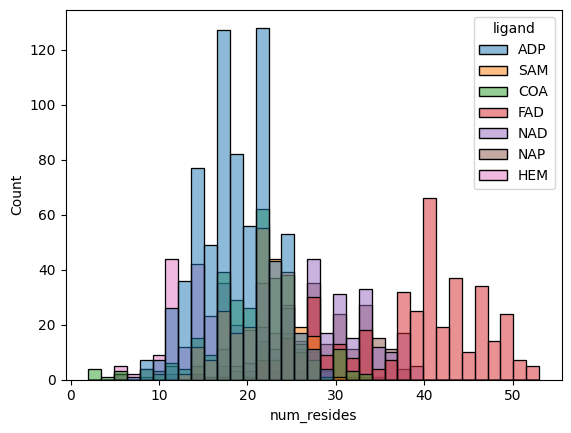

In [86]:
df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_6A_pocket_only.parquet")
pocket_size = pd.DataFrame({
    'num_resides': df['B'].apply(lambda x: len(x)), 
    'ligand': df['id'].str.split('_').str[-1]
})
pocket_size.groupby('ligand').agg(
    mean_num_resides=('num_resides', 'mean'),
    std_num_resides=('num_resides', 'std'),
)

sns.histplot(pocket_size, x='num_resides', hue='ligand')
plt.show()

## Prepare for dpocket

In [ ]:
for dist_th in range(4,13):
    dpocket_input = []
    df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A.parquet")
    for _, row in df.iterrows():
        dpocket_input.append(f"{row[]}")

In [6]:
df['id']

0         5EFQ_AB_A_ADP
1         4CRM_PX_P_ADP
2       3CR3_ACBD_B_ADP
3       3CR3_ACBD_A_ADP
4          3P4X_A_A_ADP
             ...       
2794      4NJJ_AB_B_SAM
2795      4NJJ_AB_A_SAM
2796      5C8T_AB_B_SAM
2797       2G72_A_A_SAM
2798       4FR0_A_A_SAM
Name: id, Length: 2509, dtype: object

## Train test splits

In [83]:
def _clean_pdb_chain_id(pdb_chain_id: str) -> str:
    pdb_id, chain_ids, *_ = pdb_chain_id.split('_')
    chain_ids = "".join(sorted(chain_ids))
    return pdb_id + "_" + chain_ids

train = np.load(os.path.join(MASIF_DATA_DIR, "train_pdbs_sequence.npy"))
train = train.astype(str)  # Convert byte strings to regular strings
train = [_clean_pdb_chain_id(pdb_chain_id) for pdb_chain_id in train]

val = np.load(os.path.join(MASIF_DATA_DIR, "val_pdbs_sequence.npy"))
val = val.astype(str)  # Convert byte strings to regular strings
val = [_clean_pdb_chain_id(pdb_chain_id) for pdb_chain_id in val]

test = np.load(os.path.join(MASIF_DATA_DIR, "test_pdbs_sequence.npy"))
test = test.astype(str)  # Convert byte strings to regular strings
test = [_clean_pdb_chain_id(pdb_chain_id) for pdb_chain_id in test]

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")
print(f"Train val overlap: {len(set(train) & set(val))}")
print(f"Test val overlap: {len(set(test) & set(val))}")

Train: 1036, Val: 115, Test: 287
Train val overlap: 0
Test val overlap: 0


In [84]:
def _assign_split(item_id: str) -> str:
    pdb_chain_id = _clean_pdb_chain_id(item_id)
    if pdb_chain_id in train:
        return 'train'
    elif pdb_chain_id in val:
        return 'val'
    elif pdb_chain_id in test:
        return 'test'

for dist_th in range(4,13):
    df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A_pocket_only.parquet")
    df['split'] = df['id'].apply(_assign_split)
    df.loc[df['id'] == '1FFT_ACB_A_HEM', 'split'] = 'train' # 1FFT_ABCD is in the train set of MASIF

    assert not df['split'].isna().any()

    # # Keep only the first ligand per PDB
    # # A lot of PDBs are symmetric, so we keep only the first ligand per PDB.
    # # Unclear how MASIF handle this, but this makes the dataset more comparable in size.
    # df['id_fixed'] = df['id'].apply(lambda x: "_".join(x.split('_')[:2] + x.split('_')[-1:]))
    # df = df.drop_duplicates('id_fixed')
    # df.drop(columns=['id_fixed'], inplace=True)

    for split in ['train', 'val', 'test']:
        split_df = df[df['split'] == split].copy()
        split_df.drop(columns=['split'], inplace=True)
        print(f"{split} {dist_th}A: {len(split_df)}, ligands: {split_df['id'].str.split('_').str[-1].value_counts().to_dict()}")
        split_df.to_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A_pocket_only_{split}.parquet")

train 4A: 1808, ligands: {'ADP': 526, 'FAD': 302, 'COA': 237, 'NAD': 206, 'HEM': 205, 'SAM': 187, 'NAP': 145}
val 4A: 199, ligands: {'ADP': 45, 'HEM': 29, 'NAD': 28, 'NAP': 27, 'COA': 26, 'FAD': 25, 'SAM': 19}
test 4A: 459, ligands: {'ADP': 150, 'FAD': 79, 'HEM': 56, 'SAM': 50, 'NAD': 49, 'COA': 47, 'NAP': 28}
train 5A: 1839, ligands: {'ADP': 528, 'FAD': 302, 'COA': 239, 'HEM': 229, 'NAD': 209, 'SAM': 187, 'NAP': 145}
val 5A: 203, ligands: {'ADP': 46, 'HEM': 30, 'COA': 28, 'NAD': 28, 'NAP': 27, 'FAD': 25, 'SAM': 19}
test 5A: 466, ligands: {'ADP': 150, 'FAD': 79, 'HEM': 62, 'SAM': 50, 'NAD': 49, 'COA': 48, 'NAP': 28}
train 6A: 1839, ligands: {'ADP': 528, 'FAD': 302, 'COA': 239, 'HEM': 229, 'NAD': 209, 'SAM': 187, 'NAP': 145}
val 6A: 203, ligands: {'ADP': 46, 'HEM': 30, 'COA': 28, 'NAD': 28, 'NAP': 27, 'FAD': 25, 'SAM': 19}
test 6A: 467, ligands: {'ADP': 150, 'FAD': 79, 'HEM': 62, 'SAM': 50, 'COA': 49, 'NAD': 49, 'NAP': 28}
train 7A: 1839, ligands: {'ADP': 528, 'FAD': 302, 'COA': 239, 'H

Unsure if training individually or merging is better for the different distance thresholds. So trying both.

Training individually and ensembling the results is best.

In [5]:
for split in ['train', 'val', 'test']:
    split_dfs = []
    for dist_th in range(8,13):
        split_df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A_pocket_only_{split}.parquet")
        split_dfs.append(split_df)
    split_df = pd.concat(split_dfs)
    split_df.to_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_8-12A_pocket_only_{split}.parquet")

## ATOMICA Ligand Predictions

In [37]:
def _parse_prob(x):
    """Parse a probability vector coming from CSV (often stored as a string)."""
    if isinstance(x, np.ndarray):
        return x.astype(float)
    if isinstance(x, list):
        return np.array(x, dtype=float)
    if isinstance(x, str):
        s = x.strip()
        # e.g. "[0.1, 0.2, 0.3]" (commas) or "[0.1 0.2 0.3]" (spaces)
        if "," in s:
            return np.array(ast.literal_eval(s), dtype=float)
        return np.fromstring(s.strip("[]"), sep=" ")
    return np.array([x], dtype=float)

model_ckpts = [
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_142/checkpoint/epoch186_step15895.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_206/checkpoint/epoch138_step11815.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_174/checkpoint/epoch140_step11985.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_196/checkpoint/epoch253_step21590.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_150/checkpoint/epoch286_step24395.ckpt',

#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_204/checkpoint/epoch299_step18900.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_143/checkpoint/epoch236_step14931.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_181/checkpoint/epoch275_step17388.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_162/checkpoint/epoch284_step17955.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_190/checkpoint/epoch196_step12411.ckpt',

#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_205/checkpoint/epoch222_step10258.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_180/checkpoint/epoch176_step8142.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_198/checkpoint/epoch273_step12604.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_149/checkpoint/epoch185_step8556.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_188/checkpoint/epoch223_step10304.ckpt',
]

test_preds = []
for ckpt in model_ckpts:
    if os.path.exists(os.path.join(os.path.dirname(ckpt), 'test_preds.csv')):
        test_preds.append(os.path.join(os.path.dirname(ckpt), 'test_preds.csv'))
    elif os.path.exists(os.path.join(os.path.dirname(ckpt), 'test_preds.parquet')):
        test_preds.append(os.path.join(os.path.dirname(ckpt), 'test_preds.parquet'))
    else:
        raise ValueError(f"No test predictions found for {ckpt}")

test_results = []
for i, (ckpt, test_preds) in enumerate(zip(model_ckpts, test_preds)):
    if test_preds.endswith('.csv'):
        seed_results = pd.read_csv(test_preds)
    elif test_preds.endswith('.parquet'):
        seed_results = pd.read_parquet(test_preds)
    else:
        raise ValueError(f"Unknown file type for {test_preds}")
    if 'Unnamed: 0' in seed_results.columns:
        seed_results.drop(columns=['Unnamed: 0'], inplace=True)
    seed_results['pred_probability'] = seed_results['pred_probability'].apply(lambda x: _parse_prob(x))
    seed_results['seed'] = i
    test_results.append(seed_results)
atomica_results_df = pd.concat(test_results)

In [38]:
atomica_grouped_results_df = atomica_results_df[atomica_results_df['dist_th'].isin(range(5,13))].groupby('id').agg(
    label=('label', 'first'),
    pred=('pred', list),
    pred_mode=('pred', lambda x: np.argmax(np.bincount(x))),
    pred_mode_probability=('pred_probability', lambda x: np.argmax(np.mean(x, axis=0))),
    pred_probability=('pred_probability', lambda x: np.mean(x, axis=0)),
    dist_th=('dist_th', list),
).reset_index()

atomica_grouped_results_df['pred_mode_accuracy'] = atomica_grouped_results_df['pred_mode'] == atomica_grouped_results_df['label']
atomica_grouped_results_df['pred_mode_probability_accuracy'] = atomica_grouped_results_df['pred_mode_probability'] == atomica_grouped_results_df['label']
atomica_grouped_results_df['seed'] = 0

In [39]:
# no ensemble accuracy
for dist_th in range(6,9):
    df = atomica_results_df[atomica_results_df['dist_th'] == dist_th].groupby('id').agg(
        label=('label', 'first'),
        pred=('pred', list),
        pred_mode=('pred', lambda x: np.argmax(np.bincount(x))),
        pred_mode_probability=('pred_probability', lambda x: np.argmax(np.mean(x, axis=0))),
        pred_probability=('pred_probability', lambda x: np.mean(x, axis=0)),
        dist_th=('dist_th', list),
    ).reset_index()
    accuracy = np.sum(df['pred_mode'] == df['label']) / len(df)
    accuracy_probability = np.sum(df['pred_mode_probability'] == df['label']) / len(df)
    print(f"ATOMICA Accuracy {dist_th}A: {accuracy:.4f}, {accuracy_probability:.4f}")

ATOMICA Accuracy 6A: nan, nan
ATOMICA Accuracy 7A: nan, nan
ATOMICA Accuracy 8A: 0.8544, 0.8587


/tmp/ipykernel_3966782/3344466952.py:11: RuntimeWarning: invalid value encountered in scalar divide
  accuracy = np.sum(df['pred_mode'] == df['label']) / len(df)
/tmp/ipykernel_3966782/3344466952.py:12: RuntimeWarning: invalid value encountered in scalar divide
  accuracy_probability = np.sum(df['pred_mode_probability'] == df['label']) / len(df)
/tmp/ipykernel_3966782/3344466952.py:11: RuntimeWarning: invalid value encountered in scalar divide
  accuracy = np.sum(df['pred_mode'] == df['label']) / len(df)
/tmp/ipykernel_3966782/3344466952.py:12: RuntimeWarning: invalid value encountered in scalar divide
  accuracy_probability = np.sum(df['pred_mode_probability'] == df['label']) / len(df)


## MASIF predictions

In [8]:
MASIF_PREDICTIONS_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/test_set_predictions"

In [9]:
masif_results = []
for pred_fname in glob(f"{MASIF_PREDICTIONS_DIR}/*_logits.npy"):
    item_id = os.path.basename(pred_fname).replace("_logits.npy", "")
    labels = np.load(os.path.join(MASIF_PREDICTIONS_DIR, f"{item_id}_labels.npy"))
    preds = np.load(pred_fname)
    if preds.shape == (0, ):
        print(f"No predictions for {item_id}")
        continue
    elif preds.shape[1:] != (100, 1, 1, 7):
        print(f"Invalid shape for {item_id}: {preds.shape}")
        continue
    preds = preds.mean(axis=1).squeeze()
    if preds.ndim == 1:
        preds = preds[None, :]
    for label, pred in zip(labels, preds):
        masif_results.append({
            'receptor_id': item_id,
            'label': label,
            'ligand': MASIF_LIGAND_LABELS[label],
            'pred': pred.argmax(axis=0),
            'pred_probability': pred,
        })
masif_results_df = pd.DataFrame(masif_results)
masif_results_df['pred_accuracy'] = masif_results_df['label'] == masif_results_df['pred']

No predictions for 3D36_ACB
No predictions for 2REQ_AB
No predictions for 1X7P_AB
No predictions for 2OWM_AC
No predictions for 3UQD_ACBD
No predictions for 1XX6_AB
No predictions for 4ZNL_A
No predictions for 4H6Q_A
No predictions for 5HMN_CE
No predictions for 4BLV_A
No predictions for 5L8J_AB


In [10]:
accuracy = masif_results_df['pred_accuracy'].mean()
print(f"MASIF Accuracy: {accuracy:.4f}")

MASIF Accuracy: 0.7871


### Merge the two results, since they don't have the exact same IDs
Also group the results by unique receptor and ligand pairs, as some receptors have multiple identical ligands.

In [11]:
atomica_grouped_results_df['receptor_id'] = atomica_grouped_results_df['id'].str.split('_').str[:2].str.join('_')
atomica_grouped_results_df['ligand'] = atomica_grouped_results_df['id'].str.split('_').str[-1]
atomica_grouped_results_df['masif_id'] = atomica_grouped_results_df['receptor_id'] + '_' + atomica_grouped_results_df['ligand']
masif_results_df['masif_id'] = masif_results_df['receptor_id'] + '_' + masif_results_df['ligand']

In [12]:
match_masif = atomica_grouped_results_df['masif_id'].isin(masif_results_df['masif_id'])
atomica_grouped_results_match_masif_df = atomica_grouped_results_df[match_masif].groupby('masif_id').agg(
    pred_mode_accuracy=('pred_mode_accuracy', 'mean'),
    pred_mode_probability_accuracy=('pred_mode_probability_accuracy', 'mean'),
)
atomica_grouped_results_match_masif_df.mean()

pred_mode_accuracy                0.827050
pred_mode_probability_accuracy    0.823082
dtype: float64

In [13]:
masif_results_df.groupby('masif_id').agg(
    accuracy=('pred_accuracy', 'mean'),
).mean()

accuracy    0.80754
dtype: float64

### ESM2 and ESM3 MLP predictions

In [14]:
import torch
from glob import glob

files = glob(f"/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/esm3/esm3_mlp_dist8_*/best_model.pt")
best_val_acc = 0
best_val_acc_file = None
for file in files:
    ckpt = torch.load(file)
    val_acc = ckpt['val_accuracy']
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_acc_file = file

In [15]:
best_val_acc_file

'/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/esm3/esm3_mlp_dist8_finaldim512_dropout0.2_lr5e-4/best_model.pt'

In [16]:
data_file = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/esm2_embeddings/masif_ligand_pdbs_8A_pocket_only_test_esm2.parquet"
data_df = pd.read_parquet(data_file)
with open("/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/esm2/esm2_mlp_dist8_finaldim64_dropout0.3_lr1e-3/test_predictions.json", "r") as f:
    esm2_preds = json.load(f)

results = {
    'id': data_df['id'],
    'pred_probability': esm2_preds['probabilities'],
    'label': data_df['label'],
}
esm2_results_df = pd.DataFrame(results)
esm2_results_df['seed'] = 0
esm2_results_df['dist_th'] = 8
esm2_results_df['pred'] = esm2_results_df['pred_probability'].apply(lambda x: np.argmax(x))
esm2_results_df['pred_accuracy'] = esm2_results_df['pred'] == esm2_results_df['label']
esm2_results_df['pred_accuracy'].mean()

0.8736616702355461

In [17]:
data_file = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/esm3_embeddings/masif_ligand_pdbs_8A_pocket_only_test_esm3.parquet"
data_df = pd.read_parquet(data_file)
with open("/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/esm3/esm3_mlp_dist8_finaldim512_dropout0.2_lr5e-4/test_predictions.json", "r") as f:
    esm3_preds = json.load(f)

results = {
    'id': data_df['id'],
    'pred_probability': esm3_preds['probabilities'],
    'label': data_df['label'],
}
esm3_results_df = pd.DataFrame(results)
esm3_results_df['seed'] = 0
esm3_results_df['dist_th'] = 8
esm3_results_df['pred'] = esm3_results_df['pred_probability'].apply(lambda x: np.argmax(x))
esm3_results_df['pred_accuracy'] = esm3_results_df['pred'] == esm3_results_df['label']
esm3_results_df['pred_accuracy'].mean()

0.8736616702355461

## Joint models

In [18]:
esm2_results = []

ESM2_MODEL_DIR = "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/atomica_esm2"
for dist_th in range(8,9):
    for seed in range(0, 3):
        data_file = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/atomica_esm2_embeddings/masif_ligand_pdbs_{dist_th}A_pocket_only_test_atomica_esm2_seed{seed}.parquet"
        data_df = pd.read_parquet(data_file)
        pred_file = f"{ESM2_MODEL_DIR}/atomica_esm2_mlp_dist{dist_th}_finaldim32_no_layernorm_no_l2/{seed}/test_predictions.json"
        if not os.path.exists(pred_file):
            print(f"No predictions for {dist_th}A and seed {seed}")
            continue
        with open(pred_file, 'r') as f:
            esm2_preds = json.load(f)
        if isinstance(esm2_preds, list):
            print(f"Error: ESM2 predictions are a list for dist_th {dist_th} and seed {seed}")
            continue
        results = {
            'id': data_df['id'],
            'pred_probability': esm2_preds['probabilities'],
            'label': data_df['label'],
        }
        results = pd.DataFrame(results)
        results['dist_th'] = dist_th
        results['seed'] = seed
        esm2_results.append(results)
atomica_esm2_results_df = pd.concat(esm2_results)
atomica_esm2_results_df_agg = atomica_esm2_results_df.groupby('id').agg(
    pred_probability=('pred_probability', lambda x: list(x)),
    label=('label', 'first'),
)

atomica_esm2_results_df_agg['pred_probability'] = atomica_esm2_results_df_agg['pred_probability'].apply(lambda x: np.array(x).mean(axis=0))
atomica_esm2_results_df_agg['pred'] = atomica_esm2_results_df_agg['pred_probability'].apply(lambda x: np.argmax(x))
atomica_esm2_results_df_agg['pred_accuracy'] = atomica_esm2_results_df_agg['pred'] == atomica_esm2_results_df_agg['label']
atomica_esm2_results_df_agg['pred_accuracy'].mean()

0.8886509635974305

In [19]:
esm3_results = []

ESM3_MODEL_DIR = "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/atomica_esm3"
for dist_th in range(8,9):
    for seed in range(0, 3):
        data_file = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/atomica_esm3_embeddings/masif_ligand_pdbs_{dist_th}A_pocket_only_test_atomica_esm3_seed{seed}.parquet"
        data_df = pd.read_parquet(data_file)
        pred_file = f"{ESM3_MODEL_DIR}/atomica_esm3_mlp_dist{dist_th}_finaldim32_no_layernorm_no_l2/{seed}/test_predictions.json"
        if not os.path.exists(pred_file):
            print(f"No predictions for {dist_th}A and seed {seed}")
            continue
        with open(pred_file, 'r') as f:
            esm3_preds = json.load(f)
        if isinstance(esm3_preds, list):
            print(f"Error: ESM3 predictions are a list for dist_th {dist_th} and seed {seed}")
            continue
        results = {
            'id': data_df['id'],
            'pred_probability': esm3_preds['probabilities'],
            'label': data_df['label'],
        }
        results = pd.DataFrame(results)
        results['dist_th'] = dist_th
        results['seed'] = seed
        esm3_results.append(results)
atomica_esm3_results_df = pd.concat(esm3_results)
atomica_esm3_results_df_agg = atomica_esm3_results_df.groupby('id').agg(
    pred_probability=('pred_probability', lambda x: list(x)),
    label=('label', 'first'),
)

atomica_esm3_results_df_agg['pred_probability'] = atomica_esm3_results_df_agg['pred_probability'].apply(lambda x: np.array(x).mean(axis=0))
atomica_esm3_results_df_agg['pred'] = atomica_esm3_results_df_agg['pred_probability'].apply(lambda x: np.argmax(x))
atomica_esm3_results_df_agg['pred_accuracy'] = atomica_esm3_results_df_agg['pred'] == atomica_esm3_results_df_agg['label']
atomica_esm3_results_df_agg['pred_accuracy'].mean()

0.8693790149892934

## Dpocket

In [20]:
dpocket = pd.read_parquet('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/dpocket/dpocket_mlp_predictions.parquet')
dpocket = dpocket[dpocket['split'] == 'test']
dpocket['label'] = dpocket['true_label'].apply(lambda x: MASIF_LIGAND_LABELS.index(x))
print("DPocket accuracy:", (dpocket['pred_label'] == dpocket['true_label']).mean())
dpocket

DPocket accuracy: 0.7577854671280276


,id,pred_probability,pred_label,true_label,split,label
1,4CRM_ADP,"[0.9285313, 0.007209783, 0.0061972165, 0.01575...",ADP,ADP,test,0
4,3KB1_ADP,"[0.55881494, 0.019398808, 0.0138840405, 0.0117...",ADP,ADP,test,0
16,4HLU_ADP,"[0.9686563, 0.01146111, 0.0061529833, 0.000830...",ADP,ADP,test,0
25,1NY5_ADP,"[0.88785034, 0.11167337, 0.00013036012, 6.0716...",ADP,ADP,test,0
28,5C3C_ADP,"[0.9782016, 0.017390266, 4.5706114e-05, 0.0001...",ADP,ADP,test,0
...,...,...,...,...,...,...
1434,3GYQ_SAM,"[0.82376176, 0.06098458, 0.014024705, 0.003739...",ADP,SAM,test,6
1437,4M7T_SAM,"[0.11626598, 0.008482881, 0.015345744, 0.03291...",SAM,SAM,test,6
1438,1JG4_SAM,"[0.37657812, 0.01436016, 0.20754841, 0.0082366...",ADP,SAM,test,6
1441,4NJJ_SAM,"[0.8522668, 0.013908534, 0.010071485, 0.026488...",ADP,SAM,test,6


## DrugCLIP

### DrugCLIP-Retrieval

In [21]:
DRUGCLIP_DIR = '/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/models/DrugCLIP/retrieval_results/'

# Load train, val, and test predictions
drugclip_train = pd.read_csv(f'{DRUGCLIP_DIR}/train/pocket_ligand_probabilities_mean.csv')
drugclip_val = pd.read_csv(f'{DRUGCLIP_DIR}/valid/pocket_ligand_probabilities_mean.csv')
drugclip_test = pd.read_csv(f'{DRUGCLIP_DIR}/test/pocket_ligand_probabilities_mean.csv')

# Process train
drugclip_train['true'] = drugclip_train['pocket'].apply(lambda x: x.split('_')[-1])
drugclip_train['pred_probability'] = drugclip_train.apply(lambda x: np.array(x[MASIF_LIGAND_LABELS]).astype(float), axis=1)
drugclip_train['label'] = drugclip_train['true'].apply(lambda x: MASIF_LIGAND_LABELS.index(x))

# Process val
drugclip_val['true'] = drugclip_val['pocket'].apply(lambda x: x.split('_')[-1])
drugclip_val['pred_probability'] = drugclip_val.apply(lambda x: np.array(x[MASIF_LIGAND_LABELS]).astype(float), axis=1)
drugclip_val['label'] = drugclip_val['true'].apply(lambda x: MASIF_LIGAND_LABELS.index(x))

# Process test
drugclip_test['true'] = drugclip_test['pocket'].apply(lambda x: x.split('_')[-1])
drugclip_test['pred_probability'] = drugclip_test.apply(lambda x: np.array(x[MASIF_LIGAND_LABELS]).astype(float), axis=1)
drugclip_test['label'] = drugclip_test['true'].apply(lambda x: MASIF_LIGAND_LABELS.index(x))

# Combine train and val for threshold optimization
drugclip_trainval = pd.concat([drugclip_train, drugclip_val], ignore_index=True)

# Find optimal F1 thresholds for each ligand class using train+val
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, f1_score

y_true_trainval = np.array(drugclip_trainval['label'].values)
y_pred_proba_trainval = np.stack(drugclip_trainval['pred_probability'].tolist())
y_true_bin_trainval = label_binarize(y_true_trainval, classes=np.arange(len(MASIF_LIGAND_LABELS)))

optimal_thresholds = {}
for i, ligand in enumerate(MASIF_LIGAND_LABELS):
    # Skip if class is absent
    if y_true_bin_trainval[:, i].sum() == 0:
        print(f"Warning: {ligand} has no examples in train+val, using median probability as threshold")
        # Use median probability as fallback
        optimal_thresholds[ligand] = float(np.median(y_pred_proba_trainval[:, i]))
        continue
    
    # Get precision-recall curve
    try:
        precision, recall, pr_thresholds = precision_recall_curve(y_true_bin_trainval[:, i], y_pred_proba_trainval[:, i])
        
        # Find threshold that maximizes F1
        pr_thresholds_full = np.r_[[-np.inf], pr_thresholds]  # sentinel to align lengths
        f1_vals = 2 * precision * recall / (precision + recall + 1e-12)
        
        # Check if all F1 values are NaN
        if np.all(np.isnan(f1_vals)):
            print(f"Warning: All F1 values are NaN for {ligand}, using median probability as threshold")
            optimal_thresholds[ligand] = float(np.median(y_pred_proba_trainval[:, i]))
            continue
        
        best_idx = np.nanargmax(f1_vals)
        best_thresh = pr_thresholds_full[best_idx]
        
        # For sentinel (-inf), fall back to min prob - eps
        if np.isneginf(best_thresh):
            best_thresh = y_pred_proba_trainval[:, i].min() - 1e-12
        
        optimal_thresholds[ligand] = float(best_thresh)
    except (ValueError, Exception) as e:
        print(f"Warning: Error calculating threshold for {ligand}: {e}, using median probability as threshold")
        # Use median probability as fallback
        optimal_thresholds[ligand] = float(np.median(y_pred_proba_trainval[:, i]))

print("Optimal thresholds per ligand class:")
for ligand, thresh in optimal_thresholds.items():
    print(f"  {ligand}: {thresh:.4f}")

# Apply optimal thresholds to test predictions
def predict_with_thresholds(probs, thresholds, ligand_labels):
    """
    Predict class using per-class thresholds.
    If multiple classes pass their threshold, pick the one with highest probability.
    If no classes pass, fall back to argmax.
    """
    probs = np.array(probs)
    n_classes = len(ligand_labels)
    
    # Check which classes pass their thresholds
    passed_thresholds = np.zeros(n_classes, dtype=bool)
    for i, ligand in enumerate(ligand_labels):
        thresh = thresholds[ligand]
        if not np.isnan(thresh):
            passed_thresholds[i] = probs[i] >= thresh
    
    # If exactly one class passed, return it
    if passed_thresholds.sum() == 1:
        return np.where(passed_thresholds)[0][0]
    # If multiple classes passed, return the one with highest probability
    elif passed_thresholds.sum() > 1:
        passed_indices = np.where(passed_thresholds)[0]
        return passed_indices[np.argmax(probs[passed_indices])]
    # If no classes passed, fall back to argmax
    else:
        return np.argmax(probs)

# Apply thresholds to test set
drugclip_test['pred'] = drugclip_test['pred_probability'].apply(
    lambda x: MASIF_LIGAND_LABELS[predict_with_thresholds(x, optimal_thresholds, MASIF_LIGAND_LABELS)]
)

# Also keep the argmax prediction for comparison
drugclip_test['pred_argmax'] = drugclip_test['pred_probability'].apply(lambda x: MASIF_LIGAND_LABELS[np.argmax(x)])

# Use test for drugclip variable (backward compatibility)
drugclip = drugclip_test

Optimal thresholds per ligand class:
  ADP: 0.1305
  COA: 0.1523
  FAD: 0.1495
  HEM: 0.1429
  NAD: 0.1564
  NAP: 0.1975
  SAM: 0.1590


In [22]:
drugclip['pred'].value_counts()

pred
FAD    126
NAP    111
COA     85
ADP     67
SAM     45
HEM     27
NAD      6
Name: count, dtype: int64

In [23]:
drugclip['true'].value_counts()

true
ADP    150
FAD     79
HEM     62
SAM     50
COA     49
NAD     49
NAP     28
Name: count, dtype: int64

In [24]:
drugclip[drugclip['true']==drugclip['pred']]['pred'].value_counts()

pred
ADP    61
SAM    35
FAD    22
NAP    15
COA    15
HEM    14
NAD     1
Name: count, dtype: int64

In [25]:
print(f"DrugCLIP thresholded accuracy: {(drugclip['pred']==drugclip['true']).mean()}")
print(f"DrugCLIP argmax accuracy: {(drugclip['pred_argmax']==drugclip['true']).mean()}")

DrugCLIP thresholded accuracy: 0.3490364025695932
DrugCLIP argmax accuracy: 0.28693790149892934


In [26]:
drugclip

,pocket,ADP,COA,FAD,HEM,NAD,NAP,SAM,true,pred_probability,label,pred,pred_argmax
0,4CRM_PX_P_ADP,0.174150,0.171324,0.136575,0.134130,0.121368,0.145756,0.116697,ADP,"[0.174149533560746, 0.171324067837793, 0.13657...",0,ADP,ADP
1,3KB1_AB_B_ADP,0.137761,0.155438,0.161040,0.113147,0.151357,0.183868,0.097390,ADP,"[0.1377612415491719, 0.1554384125054495, 0.161...",0,FAD,NAP
2,5C3C_ACBEDF_C_ADP,0.207903,0.160185,0.137089,0.113097,0.136872,0.122243,0.122611,ADP,"[0.2079034754674601, 0.1601853727425705, 0.137...",0,ADP,ADP
3,5ND2_ACB_C_ADP,0.218365,0.147070,0.134252,0.119142,0.132421,0.121013,0.127737,ADP,"[0.2183652676988053, 0.1470695389000468, 0.134...",0,ADP,ADP
4,2CGJ_A_A_ADP,0.135254,0.161502,0.164728,0.113198,0.157146,0.176038,0.092134,ADP,"[0.1352535543746245, 0.1615022963549898, 0.164...",0,FAD,NAP
...,...,...,...,...,...,...,...,...,...,...,...,...,...
462,1UM8_A_A_ADP,0.195690,0.174561,0.139172,0.118605,0.136981,0.123149,0.111842,ADP,"[0.1956899980209158, 0.1745609478246191, 0.139...",0,ADP,ADP
463,4Y0X_A_A_ADP,0.154035,0.140868,0.161408,0.136359,0.150945,0.144211,0.112173,ADP,"[0.1540351741797091, 0.1408683140885767, 0.161...",0,FAD,FAD
464,4J8F_AB_A_ADP,0.190812,0.152538,0.140903,0.107172,0.139908,0.133030,0.135637,ADP,"[0.1908124422600812, 0.1525380410990331, 0.140...",0,ADP,ADP
465,4J8F_AB_B_ADP,0.168970,0.161193,0.134715,0.112545,0.138737,0.153062,0.130777,ADP,"[0.1689703002424592, 0.1611932282223623, 0.134...",0,ADP,ADP


### DrugCLIP-Pocket Embeddings

Their retrieval set up works really badly, so I trained a MLP with the pocket embeddings instead.

In [27]:
with open("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/models/DrugCLIP/checkpoints/hidden_dim_512_dropout_0.0_learning_rate_1e-3/test_predictions.json", "r") as f:
    drugclip_predictions = json.load(f)
drugclip_predictions = pd.DataFrame(drugclip_predictions)
drugclip_predictions.rename(columns={'ids': 'pocket', 'probabilities': 'pred_probability', 'predictions': 'pred', 'labels': 'label'}, inplace=True)
drugclip_predictions['pred'] = drugclip_predictions['pred'].apply(lambda x: MASIF_LIGAND_LABELS[x])
drugclip_predictions['true'] = drugclip_predictions['label'].apply(lambda x: MASIF_LIGAND_LABELS[x])

In [28]:
(drugclip_predictions['pred'] == drugclip_predictions['true']).mean()

0.6895074946466809

## DeeplyTough

In [29]:
with open("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/models/DeeplyTough/checkpoints/hidden_dim_128_dropout_0.0_learning_rate_1e-3/test_predictions.json", "r") as f:
    deeplytough_predictions = json.load(f)
deeplytough_predictions = pd.DataFrame(deeplytough_predictions)
deeplytough_predictions.rename(columns={'ids': 'pocket', 'probabilities': 'pred_probability', 'predictions': 'pred', 'labels': 'label'}, inplace=True)
deeplytough_predictions['pred'] = deeplytough_predictions['pred'].apply(lambda x: MASIF_LIGAND_LABELS[x])
deeplytough_predictions['true'] = deeplytough_predictions['label'].apply(lambda x: MASIF_LIGAND_LABELS[x])

## Conclusion
MASIF and ATOMICA perform comparably. For further improvements of ATOMICA:
* ensembling different patch sizes was very useful, let's see how far we can push this.
* MASIF and ATOMICA are using different signals, so it might be useful to include some of the phsicochemical features from MASIF in the ATOMICA model.

Other baselines
* ESM 2 and ESM 3 embeddings of the pocket residues?
* Fold seek embeddings?

In [30]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score

def calculate_per_class_metrics(
    y_true,
    y_pred_proba,
    class_names=None,
    f1_mode="argmax",         # "argmax" | "fixed" | "optimal"
    fixed_threshold=0.5
):
    """
    Calculate per-class AUROC, AUPRC, and F1 for multiclass classification.

    Args:
        y_true: array-like of shape (n_samples,), int labels in [0, n_classes-1]
        y_pred_proba: array of shape (n_samples, n_classes), class probabilities
        class_names: optional list of names of length n_classes
        f1_mode:
            - "argmax": derive hard labels via argmax over classes
            - "fixed": per-class one-vs-rest thresholding at `fixed_threshold`
            - "optimal": per-class threshold chosen to maximize F1 on PR curve
        fixed_threshold: threshold used when f1_mode="fixed"
    Returns:
        dict with per-class metrics and macro averages
    """
    y_true = np.asarray(y_true)
    n_classes = y_pred_proba.shape[1]
    if class_names is None:
        class_names = [f"Class_{i}" for i in range(n_classes)]

    # One-vs-rest binarized ground truth
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    results = {}
    thresholds_used = {}

    # If using argmax, compute hard predictions once
    if f1_mode == "argmax":
        y_pred_hard = y_pred_proba.argmax(axis=1)

    for i in range(n_classes):
        cls = class_names[i]

        # skip classes absent in y_true
        if y_true_bin[:, i].sum() == 0:
            results[f"{cls}_AUROC"] = np.nan
            results[f"{cls}_AUPRC"] = np.nan
            results[f"{cls}_F1"] = np.nan
            thresholds_used[cls] = np.nan
            continue

        # AUROC (OvR)
        try:
            results[f"{cls}_AUROC"] = roc_auc_score(y_true_bin[:, i], y_pred_proba[:, i])
        except ValueError:
            results[f"{cls}_AUROC"] = np.nan

        # AUPRC (OvR)
        try:
            precision, recall, pr_thresholds = precision_recall_curve(y_true_bin[:, i], y_pred_proba[:, i])
            results[f"{cls}_AUPRC"] = auc(recall, precision)
        except ValueError:
            precision = recall = pr_thresholds = None
            results[f"{cls}_AUPRC"] = np.nan

        # F1 (choose strategy)
        if f1_mode == "argmax":
            # Standard multiclass F1 computed from hard labels
            f1s = f1_score(y_true, y_pred_hard, average=None, labels=np.arange(n_classes))
            results[f"{cls}_F1"] = f1s[i]
            thresholds_used[cls] = "argmax"
        elif f1_mode == "fixed":
            y_pred_bin_i = (y_pred_proba[:, i] >= fixed_threshold).astype(int)
            results[f"{cls}_F1"] = f1_score(y_true_bin[:, i], y_pred_bin_i)
            thresholds_used[cls] = fixed_threshold
        elif f1_mode == "optimal":
            # pick threshold that maximizes F1 on PR curve
            if precision is None or recall is None or pr_thresholds is None:
                results[f"{cls}_F1"] = np.nan
                thresholds_used[cls] = np.nan
            else:
                # precision, recall length = len(thresholds)+1; align by dropping first point
                pr_thresholds_full = np.r_[[-np.inf], pr_thresholds]  # sentinel to align lengths
                f1_vals = 2 * precision * recall / (precision + recall + 1e-12)
                best_idx = np.nanargmax(f1_vals)
                best_thresh = pr_thresholds_full[best_idx]
                # For sentinel (−inf), fall back to min prob − eps to classify almost all as positive
                if np.isneginf(best_thresh):
                    best_thresh = y_pred_proba[:, i].min() - 1e-12
                y_pred_bin_i = (y_pred_proba[:, i] >= best_thresh).astype(int)
                results[f"{cls}_F1"] = f1_score(y_true_bin[:, i], y_pred_bin_i)
                thresholds_used[cls] = float(best_thresh)
        else:
            raise ValueError("f1_mode must be 'argmax', 'fixed', or 'optimal'.")

    # Macro averages (ignore NaNs)
    auroc_vals = [v for k, v in results.items() if k.endswith("_AUROC") and not np.isnan(v)]
    auprc_vals = [v for k, v in results.items() if k.endswith("_AUPRC") and not np.isnan(v)]
    f1_vals =   [v for k, v in results.items() if k.endswith("_F1")    and not np.isnan(v)]

    results["Macro_Avg_AUROC"] = np.mean(auroc_vals) if auroc_vals else np.nan
    results["Macro_Avg_AUPRC"] = np.mean(auprc_vals) if auprc_vals else np.nan
    results["Macro_Avg_F1"] = np.mean(f1_vals) if f1_vals else np.nan
    results["Micro_Avg_F1"] = f1_score(y_true, y_pred_hard, average='micro')
    results["_thresholds_used"] = thresholds_used  # optional: helpful for debugging

    return results

In [41]:
# Compute metrics with per-seed variation for error bars
def compute_metrics_per_seed(results_df, model_name):
    """
    Compute metrics for each seed separately to get error bars.
    Returns a dict with metric means and stds.
    """
    # All models should now have a 'seed' column
    if 'seed' not in results_df.columns:
        raise ValueError(f"Model {model_name} does not have a 'seed' column!")
    
    seeds = sorted(results_df['seed'].unique())
    seed_metrics = []
    
    for seed_idx in seeds:
        # Filter for this seed
        seed_df = results_df[results_df['seed'] == seed_idx].copy()
        
        # Aggregate across distance thresholds for this seed
        # Convert pred_probability to list first, then average
        seed_agg_data = []
        for item_id in seed_df['id'].unique():
            item_rows = seed_df[seed_df['id'] == item_id]
            # Stack all pred_probabilities for this item and take mean
            probs = np.array([p for p in item_rows['pred_probability'].values])
            mean_prob = np.mean(probs, axis=0)
            seed_agg_data.append({
                'id': item_id,
                'pred_probability': mean_prob,
                'label': item_rows['label'].iloc[0]
            })
        seed_agg = pd.DataFrame(seed_agg_data)
        
        # Compute metrics for this seed
        y_true = seed_agg['label'].values
        y_pred_proba = np.stack(seed_agg['pred_probability'].values)
        
        metrics = calculate_per_class_metrics(y_true, y_pred_proba, MASIF_LIGAND_LABELS)
        seed_metrics.append(metrics)
    
    # Compute mean and std across seeds
    metrics_with_error = {}
    for metric_name in seed_metrics[0].keys():
        if metric_name == '_thresholds_used':
            continue
        values = [m[metric_name] for m in seed_metrics if not (isinstance(m[metric_name], float) and np.isnan(m[metric_name]))]
        if values:
            metrics_with_error[metric_name] = {
                'mean': np.mean(values),
                'std': np.std(values)
            }
        else:
            metrics_with_error[metric_name] = {'mean': np.nan, 'std': 0}
    
    return metrics_with_error

# Compute metrics with error bars for models with multiple seeds
atomica_metrics_with_error = compute_metrics_per_seed(atomica_grouped_results_df, 'ATOMICA')
esm2_metrics_with_error = compute_metrics_per_seed(esm2_results_df, 'ESM2')
esm3_metrics_with_error = compute_metrics_per_seed(esm3_results_df, 'ESM3')
atomica_esm2_metrics_with_error = compute_metrics_per_seed(atomica_esm2_results_df, 'ATOMICA ESM2')

# Build metrics table with error bars
metrics_table = []
metrics_table_with_errors = []

# DPocket (no seeds, no error bars)
dpocket_metrics = calculate_per_class_metrics(dpocket['label'], np.stack(dpocket['pred_probability'].tolist()), MASIF_LIGAND_LABELS)
for metric, value in dpocket_metrics.items():
    if metric != '_thresholds_used':
        metrics_table.append({
            'Model': 'DPocket',
            'Metric': metric,
            'Value': value
        })
        metrics_table_with_errors.append({
            'Model': 'DPocket',
            'Metric': metric,
            'Mean': value,
            'Std': 0.0
        })

# DeeplyTough (no seeds, no error bars)
deeplytough_metrics = calculate_per_class_metrics(deeplytough_predictions['label'], np.stack(deeplytough_predictions['pred_probability'].tolist()), MASIF_LIGAND_LABELS)
for metric, value in deeplytough_metrics.items():
    if metric != '_thresholds_used':
        metrics_table.append({
            'Model': 'DeeplyTough',
            'Metric': metric,
            'Value': value
        })
        metrics_table_with_errors.append({
            'Model': 'DeeplyTough',
            'Metric': metric,
            'Mean': value,
            'Std': 0.0
        })

# MASIF (no seeds, no error bars)
masif_metrics = calculate_per_class_metrics(masif_results_df['label'], np.stack(masif_results_df['pred_probability'].tolist()), MASIF_LIGAND_LABELS)
for metric, value in masif_metrics.items():
    if metric != '_thresholds_used':
        metrics_table.append({
            'Model': 'MASIF',
            'Metric': metric,
            'Value': value
        })
        metrics_table_with_errors.append({
            'Model': 'MASIF',
            'Metric': metric,
            'Mean': value,
            'Std': 0.0
        })

# ESM2 (with error bars)
for metric, stats in esm2_metrics_with_error.items():
    metrics_table.append({
        'Model': 'ESM2',
        'Metric': metric,
        'Value': stats['mean']
    })
    metrics_table_with_errors.append({
        'Model': 'ESM2',
        'Metric': metric,
        'Mean': stats['mean'],
        'Std': stats['std']
    })

# ESM3 (with error bars)
for metric, stats in esm3_metrics_with_error.items():
    metrics_table.append({
        'Model': 'ESM3',
        'Metric': metric,
        'Value': stats['mean']
    })
    metrics_table_with_errors.append({
        'Model': 'ESM3',
        'Metric': metric,
        'Mean': stats['mean'],
        'Std': stats['std']
    })

# ATOMICA (with error bars)
for metric, stats in atomica_metrics_with_error.items():
    metrics_table.append({
        'Model': 'ATOMICA',
        'Metric': metric,
        'Value': stats['mean']
    })
    metrics_table_with_errors.append({
        'Model': 'ATOMICA',
        'Metric': metric,
        'Mean': stats['mean'],
        'Std': stats['std']
    })

# ATOMICA ESM2 (with error bars)
for metric, stats in atomica_esm2_metrics_with_error.items():
    metrics_table.append({
        'Model': 'ATOMICA ESM2',
        'Metric': metric,
        'Value': stats['mean']
    })
    metrics_table_with_errors.append({
        'Model': 'ATOMICA ESM2',
        'Metric': metric,
        'Mean': stats['mean'],
        'Std': stats['std']
    })

# DrugCLIP (no seeds, no error bars)
drugclip_metrics = calculate_per_class_metrics(drugclip_predictions['label'], np.stack(drugclip_predictions['pred_probability'].tolist()), MASIF_LIGAND_LABELS)
for metric, value in drugclip_metrics.items():
    if metric != '_thresholds_used':
        metrics_table.append({
            'Model': 'DrugCLIP',
            'Metric': metric,
            'Value': value
        })
        metrics_table_with_errors.append({
            'Model': 'DrugCLIP',
            'Metric': metric,
            'Mean': value,
            'Std': 0.0
        })


metrics_table_df = pd.DataFrame(metrics_table)
metrics_table_with_errors_df = pd.DataFrame(metrics_table_with_errors)

metrics_table_df.pivot(index='Metric', columns='Model', values='Value')

Model,ATOMICA,ATOMICA ESM2,DPocket,DeeplyTough,DrugCLIP,ESM2,ESM3,MASIF
Metric,,,,,,,,
ADP_AUPRC,0.969934,0.951279,0.892091,0.502626,0.921600,0.948497,0.955492,0.930552
ADP_AUROC,0.977876,0.951399,0.935341,0.689048,0.947476,0.948223,0.953922,0.928182
ADP_F1,0.919861,0.891812,0.810000,0.564948,0.846416,0.880259,0.891803,0.855967
COA_AUPRC,0.818968,0.940272,0.647882,0.228767,0.635585,0.919349,0.880763,0.668321
COA_AUROC,0.928718,0.986704,0.929858,0.662480,0.863002,0.983449,0.977785,0.935629
COA_F1,0.755556,0.873386,0.560000,0.137931,0.576923,0.851064,0.791209,0.650602
FAD_AUPRC,0.920967,0.980468,0.823643,0.264573,0.829804,0.961041,0.967044,0.773617
FAD_AUROC,0.970508,0.996226,0.971426,0.685332,0.955403,0.993801,0.993116,0.940329
FAD_F1,0.864516,0.936855,0.804124,0.149533,0.734940,0.926829,0.945455,0.766667


/tmp/ipykernel_3966782/1525544938.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df['Metric'].str.replace('_AUROC', ''))


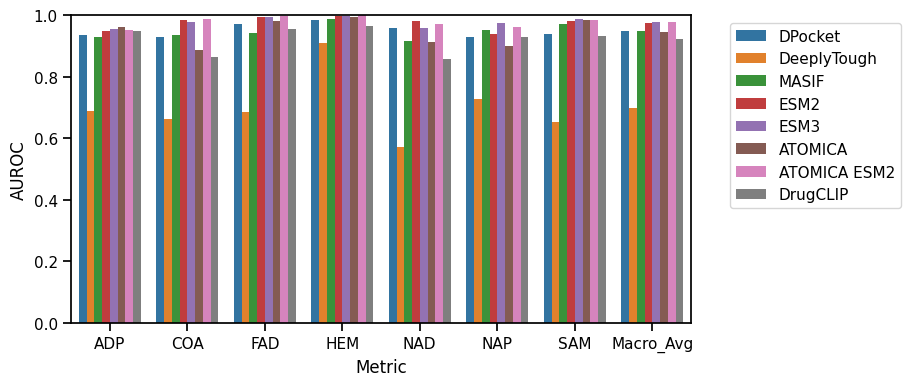

In [32]:
plot_df = metrics_table_df[metrics_table_df['Metric'].str.endswith('AUROC')]
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=plot_df, x='Metric', y='Value', hue='Model', ax=ax)
ax.set_ylim(0.0, 1.0)
ax.set_xticklabels(plot_df['Metric'].str.replace('_AUROC', ''))
ax.set_ylabel('AUROC')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

/tmp/ipykernel_3966782/1625497113.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df['Metric'].str.replace('_AUPRC', ''))


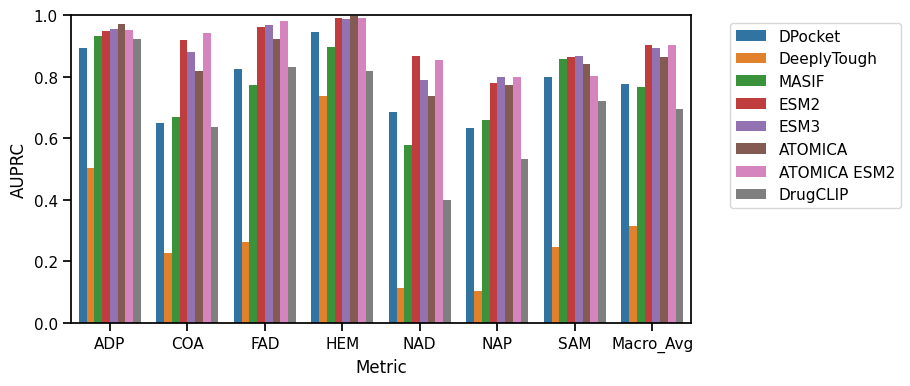

In [42]:
plot_df = metrics_table_df[metrics_table_df['Metric'].str.endswith('AUPRC')]
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=plot_df, x='Metric', y='Value', hue='Model', ax=ax)
ax.set_ylim(0.0, 1.0)
ax.set_xticklabels(plot_df['Metric'].str.replace('_AUPRC', ''))
ax.set_ylabel('AUPRC')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

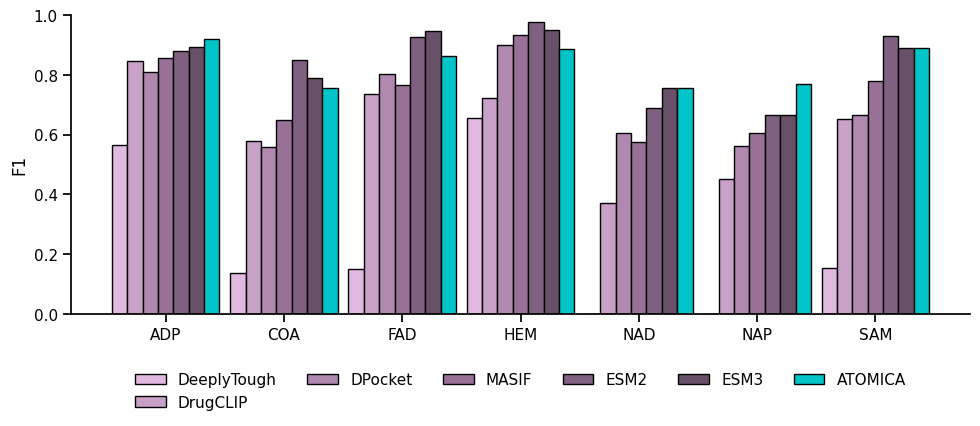

In [43]:
# Plot per-class F1 scores with error bars
plot_df = metrics_table_with_errors_df[
    metrics_table_with_errors_df['Metric'].str.endswith('F1') & 
    ~metrics_table_with_errors_df['Metric'].str.contains('Avg')
].copy()

fig, ax = plt.subplots(figsize=(10, 4.5))

# Define colors
palette = ['#E0B8E0', '#C8A0C8', '#B088B0', '#987098', '#806080', '#685068', atomica_color]
# palette = ['#E0B8E0', '#C8A0C8', '#B088B0', atomica_color]


# Get unique metrics and models
metrics_order = plot_df['Metric'].unique()
models = ['DeeplyTough', 'DrugCLIP', 'DPocket', 'MASIF', 'ESM2', 'ESM3', 'ATOMICA']
# models = ['DPocket', 'DrugCLIP', 'MASIF', 'ATOMICA']

# Prepare data for plotting
x_labels = [m.replace('_F1', '') for m in metrics_order]
x = np.arange(len(x_labels))
width = 0.13  # Width of each bar
offsets = np.linspace(-width * (len(models) - 1) / 2, width * (len(models) - 1) / 2, len(models))

# Plot bars with error bars
for i, model in enumerate(models):
    model_data = plot_df[plot_df['Model'] == model]
    means = [model_data[model_data['Metric'] == m]['Mean'].values[0] if len(model_data[model_data['Metric'] == m]) > 0 else 0 for m in metrics_order]
    stds = [model_data[model_data['Metric'] == m]['Std'].values[0] if len(model_data[model_data['Metric'] == m]) > 0 else 0 for m in metrics_order]
    
    ax.bar(x + offsets[i], means, width, label=model, color=palette[i], 
           edgecolor='black', linewidth=1, yerr=stds, capsize=0, error_kw={'linewidth': 1})

sns.despine()
ax.set_ylim(0.0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel('F1')
ax.set_xlabel('')

plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=6, frameon=False)
plt.tight_layout()
plt.savefig('masif_ligand_benchmark_f1.svg', format='svg', bbox_inches='tight')
plt.show()

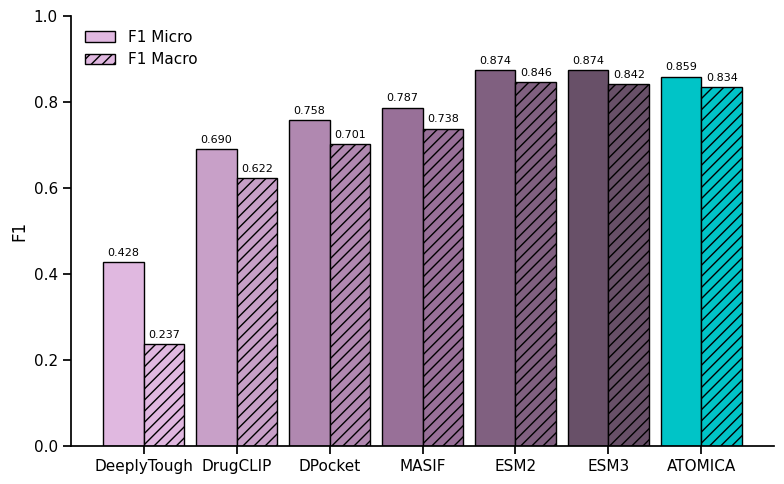

In [44]:
# Plot F1 Macro and Micro averages with error bars
plot_df = metrics_table_with_errors_df[
    metrics_table_with_errors_df['Metric'].str.endswith('F1') & 
    metrics_table_with_errors_df['Metric'].str.contains('Avg')
].copy()



# Separate micro and macro
micro_df = plot_df[plot_df['Metric'].str.contains('Micro')].copy()
macro_df = plot_df[plot_df['Metric'].str.contains('Macro')].copy()

# Get unique models in order
# models = ['DPocket', 'MASIF', 'ESM2', 'ESM3', 'ATOMICA', 'ATOMICA ESM2']
models = ['DPocket', 'DrugCLIP', 'MASIF', 'ATOMICA']
models = ['DeeplyTough', 'DrugCLIP', 'DPocket', 'MASIF',  'ESM2', 'ESM3', 'ATOMICA']
plot_df = plot_df[plot_df['Model'].isin(models)]
n_models = len(models)

# Prepare data for grouped bars
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values and errors for both metrics for each model
f1_micro_means = []
f1_micro_stds = []
f1_macro_means = []
f1_macro_stds = []

for model in models:
    micro_vals = micro_df[micro_df['Model'] == model]
    macro_vals = macro_df[macro_df['Model'] == model]
    
    f1_micro_means.append(micro_vals['Mean'].values[0] if len(micro_vals) > 0 else 0)
    f1_micro_stds.append(micro_vals['Std'].values[0] if len(micro_vals) > 0 else 0)
    f1_macro_means.append(macro_vals['Mean'].values[0] if len(macro_vals) > 0 else 0)
    f1_macro_stds.append(macro_vals['Std'].values[0] if len(macro_vals) > 0 else 0)

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Define colors for models
# model_colors = ['#E0B8E0', '#C8A0C8', '#B088B0', '#987098', atomica_color, ensemble_color]
model_colors = ['#E0B8E0', '#C8A0C8', '#B088B0', atomica_color]
model_colors = ['#E0B8E0', '#C8A0C8', '#B088B0', '#987098', '#806080', '#685068', atomica_color]


# Plot bars side by side with error bars
# f1_micro bars (left, solid)
for i, model in enumerate(models):
    ax.bar(x[i] - width/2, f1_micro_means[i], width, 
           color=model_colors[i], edgecolor='black', linewidth=1, 
           yerr=f1_micro_stds[i], capsize=0, error_kw={'linewidth': 1})

# f1_macro bars (right, with diagonal hatching)
for i, model in enumerate(models):
    ax.bar(x[i] + width/2, f1_macro_means[i], width, 
           color=model_colors[i], edgecolor='black', linewidth=1,
           hatch='///', yerr=f1_macro_stds[i], capsize=0, error_kw={'linewidth': 1})

# Add text labels on top of bars
for i in range(n_models):
    # F1 Micro label
    y_pos_micro = f1_micro_means[i] + f1_micro_stds[i] + 0.01
    ax.text(x[i] - width/2, y_pos_micro, f'{f1_micro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=8, rotation=0)
    
    # F1 Macro label
    y_pos_macro = f1_macro_means[i] + f1_macro_stds[i] + 0.01
    ax.text(x[i] + width/2, y_pos_macro, f'{f1_macro_means[i]:.3f}', 
            ha='center', va='bottom', fontsize=8, rotation=0)

# Create custom legend with grey color
from matplotlib.patches import Rectangle
legend_elements = [
    Rectangle((0, 0), 1, 1, facecolor='#E0B8E0', edgecolor='black', label='F1 Micro'),
    Rectangle((0, 0), 1, 1, facecolor='#E0B8E0', edgecolor='black', hatch='///', label='F1 Macro')
]
ax.legend(handles=legend_elements, loc='best', frameon=False)

# Customize the plot
ax.set_ylabel('F1', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_ylim(0.0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(models)
sns.despine()

plt.tight_layout()
plt.savefig('masif_ligand_benchmark_f1_avg.svg', format='svg', bbox_inches='tight')
plt.show()